In [6]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [7]:
import zipfile
import os
zip_file = "/content/archive (2).zip"
extract_path = "/content/cattle_dataset"
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
dataset_path = "/content/cattle_dataset/Cows datasets"
print("Classes:")
print(os.listdir(dataset_path))

Classes:
['foot-and-mouth', 'healthy', 'lumpy']


In [13]:
for folder in os.listdir(dataset_path):
  folder_path = os.path.join(dataset_path, folder)
  if os.path.isdir(folder_path):
    count = len([
f for f in os.listdir(folder_path)
if f.lower().endswith((".jpg", ".jpeg", ".png"))
])
print(folder, ":", count, "images")

lumpy : 1207 images


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)
test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 2596 images belonging to 3 classes.
Found 648 images belonging to 3 classes.


In [16]:
print("Class names:")
print(train_data.class_indices)

Class names:
{'foot-and-mouth': 0, 'healthy': 1, 'lumpy': 2}


In [17]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax")
])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully!")

Model compiled successfully!


In [19]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - accuracy: 0.6059 - loss: 0.8673 - val_accuracy: 0.6265 - val_loss: 0.8697
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 316s 4s/step - accuracy: 0.7361 - loss: 0.6477 - val_accuracy: 0.6559 - val_loss: 0.9022
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 313s 4s/step - accuracy: 0.7735 - loss: 0.5492 - val_accuracy: 0.6528 - val_loss: 0.8487
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 311s 4s/step - accuracy: 0.8120 - loss: 0.4758 - val_accuracy: 0.6975 - val_loss: 0.7961
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 324s 4s/step - accuracy: 0.8721 - loss: 0.3373 - val_accuracy: 0.6975 - val_loss: 0.8853
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.9060 - loss: 0.2608 - val_accuracy: 0.7068 - val_loss: 1.0571
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 314s 4s/step - accuracy: 0.9341 - loss: 0.1801 - val_accuracy: 0.6914 - val_loss: 1.1971
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 316s 4s/step - accuracy: 0.9364 - loss: 0.1632 - val_accuracy: 0.6975 - v

In [20]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", round(accuracy * 100, 2), "%")

21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6991 - loss: 1.9700
Test Accuracy: 69.91 %


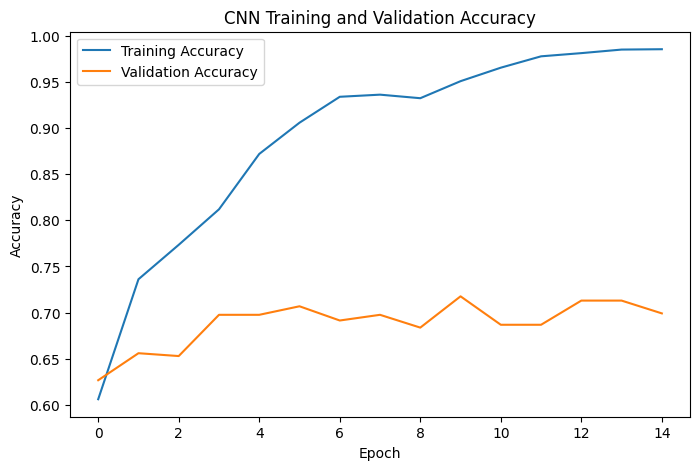

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

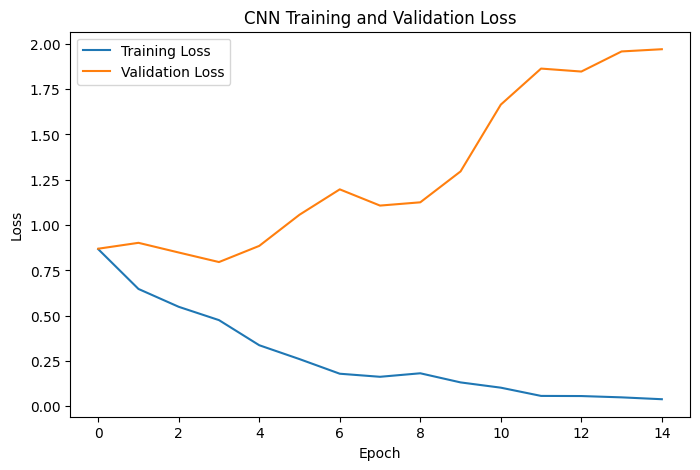

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [23]:
from google.colab import files
uploaded_image = files.upload()

Saving -50-_jpg.rf.dd8523974ad4b4c1e6fefaab15cb859f.jpg to -50-_jpg.rf.dd8523974ad4b4c1e6fefaab15cb859f.jpg


In [24]:
from tensorflow.keras.utils import load_img, img_to_array
image_name = list(uploaded_image.keys())[0]
img = load_img(image_name, target_size=(224, 224))
img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction[0])
class_names = list(train_data.class_indices.keys())
predicted_disease = class_names[predicted_index]
confidence = np.max(prediction[0]) * 100
print("Predicted Disease:", predicted_disease)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Predicted Disease: healthy
Confidence: 98.68 %
